# Установка и импорт библиотек

In [3]:
!pip -q install transformers torch matplotlib seaborn bertviz

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# Загрузка моделей при помощи transformers

In [5]:
bert_name = "bert-base-uncased"
gpt2_name = "gpt2"

bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModel.from_pretrained(bert_name, output_attentions=True).to(device)
bert_model.eval()

gpt2_tokenizer = AutoTokenizer.from_pretrained(gpt2_name)
gpt2_model = AutoModelForCausalLM.from_pretrained(gpt2_name, output_attentions=True).to(device)
gpt2_model.eval()

if gpt2_tokenizer.pad_token is None:
    gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

print("BERT loaded:", bert_name)
print("GPT-2 loaded:", gpt2_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


BERT loaded: bert-base-uncased
GPT-2 loaded: gpt2


BERT = bidirectional encoder (видит и левый, и правый контекст)

GPT-2 = causal decoder (видит только прошлые токены)

# Извлечение attention

In [6]:
text = "Attention is all you need"
print(text)

Attention is all you need


In [7]:
def get_attention(model, tokenizer, text, model_type="bert", device="cpu"):
    """
    Возвращает:
    - attentions: tuple[num_layers] -> tensor(batch, heads, seq_len, seq_len)
    - tokens: список токенов
    """
    inputs = tokenizer(text, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = outputs.attentions  # tuple: len=num_layers
    #print(outputs)
    input_ids = inputs["input_ids"][0].detach().cpu().tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    return attentions, tokens


In [8]:
bert_attn, bert_tokens = get_attention(bert_model, bert_tokenizer, text, "bert", device=device)
gpt2_attn, gpt2_tokens = get_attention(gpt2_model, gpt2_tokenizer, text, "gpt2", device=device)

print("BERT layers:", len(bert_attn), "heads:", bert_attn[0].shape[1], "seq_len:", bert_attn[0].shape[-1])
print("GPT2 layers:", len(gpt2_attn), "heads:", gpt2_attn[0].shape[1], "seq_len:", gpt2_attn[0].shape[-1])

print("\nBERT tokens:", bert_tokens)
print("\nGPT-2 tokens:", gpt2_tokens)


BERT layers: 12 heads: 12 seq_len: 7
GPT2 layers: 12 heads: 12 seq_len: 6

BERT tokens: ['[CLS]', 'attention', 'is', 'all', 'you', 'need', '[SEP]']

GPT-2 tokens: ['Att', 'ention', 'Ġis', 'Ġall', 'Ġyou', 'Ġneed']


In [9]:
def print_attention_snippet(attentions, tokens, layer=0, head=0, n=8, model_name="MODEL"):
    """
    Печатает кусок матрицы attention: n x n (первые токены)
    """
    attn = attentions[layer][0, head].detach().cpu().numpy()  # (seq_len, seq_len)

    print(f"\n===== {model_name} | layer={layer}, head={head} =====")
    print("Tokens snippet:", tokens[:n])

    print(f"\nAttention matrix snippet ({n}x{n}):")
    np.set_printoptions(precision=3, suppress=True)
    print(attn[:n, :n])

    print("\nRow sums (should be ~1.0):")
    print(attn[:n, :n].sum(axis=1))

# Смотрим слой=0, голова=0
print_attention_snippet(bert_attn, bert_tokens, layer=0, head=0, n=8, model_name="BERT")
print_attention_snippet(gpt2_attn, gpt2_tokens, layer=0, head=0, n=8, model_name="GPT-2")



===== BERT | layer=0, head=0 =====
Tokens snippet: ['[CLS]', 'attention', 'is', 'all', 'you', 'need', '[SEP]']

Attention matrix snippet (8x8):
[[0.094 0.11  0.067 0.108 0.063 0.065 0.492]
 [0.221 0.05  0.167 0.075 0.146 0.122 0.22 ]
 [0.188 0.05  0.168 0.162 0.166 0.199 0.067]
 [0.151 0.06  0.169 0.106 0.166 0.166 0.182]
 [0.188 0.093 0.116 0.111 0.128 0.194 0.17 ]
 [0.26  0.062 0.225 0.073 0.126 0.094 0.16 ]
 [0.171 0.069 0.116 0.158 0.158 0.079 0.249]]

Row sums (should be ~1.0):
[1. 1. 1. 1. 1. 1. 1.]

===== GPT-2 | layer=0, head=0 =====
Tokens snippet: ['Att', 'ention', 'Ġis', 'Ġall', 'Ġyou', 'Ġneed']

Attention matrix snippet (8x8):
[[1.    0.    0.    0.    0.    0.   ]
 [0.92  0.08  0.    0.    0.    0.   ]
 [0.627 0.297 0.076 0.    0.    0.   ]
 [0.485 0.255 0.174 0.085 0.    0.   ]
 [0.614 0.239 0.041 0.06  0.046 0.   ]
 [0.438 0.199 0.14  0.053 0.075 0.095]]

Row sums (should be ~1.0):
[1. 1. 1. 1. 1. 1.]


In [10]:
import numpy as np

def print_causal_mask(tokens, n=12):
    """
    causal mask для GPT-2:
    1 = можно смотреть
    0 = нельзя (будущее)
    """
    seq_len = len(tokens)
    n = min(n, seq_len)

    mask = np.tril(np.ones((seq_len, seq_len), dtype=int))  # нижний треугольник
    print("\n===== GPT-2 CAUSAL MASK (1=allowed, 0=blocked) =====")
    print("Tokens snippet:", tokens[:n])
    print(mask[:n, :n])

def check_future_attention(attentions, tokens, layer=0, head=0, n=12):
    """
    Проверяем, что GPT-2 почти не смотрит в будущее
    """
    attn = attentions[layer][0, head].detach().cpu().numpy()  # (seq, seq)
    seq_len = attn.shape[0]
    n = min(n, seq_len)

    # верхний треугольник (будущее) без диагонали
    future_part = np.triu(attn, k=1)

    print(f"\n===== GPT-2 FUTURE ATTENTION CHECK | layer={layer}, head={head} =====")
    print("Tokens snippet:", tokens[:n])

    print("\nAttention snippet (n x n):")
    np.set_printoptions(precision=3, suppress=True)
    print(attn[:n, :n])

    print("\nMax attention to FUTURE (should be ~0):", future_part.max())

# Печатаем маску (сделаем n=12, можно уменьшить/увеличить)
print_causal_mask(gpt2_tokens, n=12)

# Проверяем на конкретной голове
check_future_attention(gpt2_attn, gpt2_tokens, layer=0, head=0, n=12)



===== GPT-2 CAUSAL MASK (1=allowed, 0=blocked) =====
Tokens snippet: ['Att', 'ention', 'Ġis', 'Ġall', 'Ġyou', 'Ġneed']
[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]

===== GPT-2 FUTURE ATTENTION CHECK | layer=0, head=0 =====
Tokens snippet: ['Att', 'ention', 'Ġis', 'Ġall', 'Ġyou', 'Ġneed']

Attention snippet (n x n):
[[1.    0.    0.    0.    0.    0.   ]
 [0.92  0.08  0.    0.    0.    0.   ]
 [0.627 0.297 0.076 0.    0.    0.   ]
 [0.485 0.255 0.174 0.085 0.    0.   ]
 [0.614 0.239 0.041 0.06  0.046 0.   ]
 [0.438 0.199 0.14  0.053 0.075 0.095]]

Max attention to FUTURE (should be ~0): 0.0


In [11]:
def safe_get(obj, attr, default=None):
    return getattr(obj, attr, default)

def print_config_summary(model, model_name="MODEL"):
    cfg = model.config
    print(f"\n==================== {model_name} CONFIG SUMMARY ====================")
    print("model class:", model.__class__.__name__)
    print("config class:", cfg.__class__.__name__)
    print("model_type:", safe_get(cfg, "model_type"))

    num_layers = safe_get(cfg, "num_hidden_layers", safe_get(cfg, "n_layer"))
    num_heads  = safe_get(cfg, "num_attention_heads", safe_get(cfg, "n_head"))
    hidden     = safe_get(cfg, "hidden_size", safe_get(cfg, "n_embd"))
    ff_dim     = safe_get(cfg, "intermediate_size", default=None)
    vocab      = safe_get(cfg, "vocab_size")
    max_pos    = safe_get(cfg, "max_position_embeddings", safe_get(cfg, "n_positions"))
    dropout    = safe_get(cfg, "hidden_dropout_prob", safe_get(cfg, "resid_pdrop"))

    print("vocab_size:", vocab)
    print("max_position_embeddings:", max_pos)
    print("num_layers:", num_layers)
    print("num_heads:", num_heads)
    print("hidden_size / n_embd:", hidden)
    if ff_dim is not None:
        print("ff/intermediate_size:", ff_dim)
    if dropout is not None:
        print("dropout:", dropout)

    if hidden is not None and num_heads is not None:
        print("head_dim =", hidden // num_heads, "(hidden_size / num_heads)")

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def print_param_count(model, model_name="MODEL"):
    total, trainable = count_parameters(model)
    print(f"\n==================== {model_name} PARAM COUNT ====================")
    print("total params:", f"{total:,}")
    print("trainable params:", f"{trainable:,}")

def print_module_tree(model, model_name="MODEL", max_depth=3, max_children=40):
    """
    Печатает дерево модулей без весов.
    max_depth — насколько глубоко заходить
    max_children — ограничение по количеству дочерних модулей на уровень (чтобы не заспамить)
    """
    print(f"\n==================== {model_name} MODULE TREE (depth={max_depth}) ====================")

    def recurse(module, prefix="", depth=0):
        if depth > max_depth:
            return

        children = list(module.named_children())
        if not children:
            return

        if len(children) > max_children:
            children = children[:max_children] + [("...more", None)]

        for name, child in children:
            if child is None:
                print(prefix + "└── ... (too many submodules)")
                continue
            print(prefix + f"└── {name}: {child.__class__.__name__}")
            recurse(child, prefix + "    ", depth + 1)

    print(f"{model.__class__.__name__}")
    recurse(model, prefix="", depth=0)


## Структура модели BERT

In [62]:
print_config_summary(bert_model, "BERT")
print_param_count(bert_model, "BERT")
print_module_tree(bert_model, "BERT", max_depth=3)


==================== BERT CONFIG SUMMARY ====================
model class: BertModel
config class: BertConfig
model_type: bert
vocab_size: 30522
max_position_embeddings: 512
num_layers: 12
num_heads: 12
hidden_size / n_embd: 768
ff/intermediate_size: 3072
dropout: 0.1
head_dim = 64 (hidden_size / num_heads)

==================== BERT PARAM COUNT ====================
total params: 109,482,240
trainable params: 109,482,240

==================== BERT MODULE TREE (depth=3) ====================
BertModel
└── embeddings: BertEmbeddings
    └── word_embeddings: Embedding
    └── position_embeddings: Embedding
    └── token_type_embeddings: Embedding
    └── LayerNorm: LayerNorm
    └── dropout: Dropout
└── encoder: BertEncoder
    └── layer: ModuleList
        └── 0: BertLayer
            └── attention: BertAttention
            └── intermediate: BertIntermediate
            └── output: BertOutput
        └── 1: BertLayer
            └── attention: BertAttention
            └── intermediate:

In [63]:
print(bert_model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

## Структура модели GPT-2

In [12]:
print_config_summary(gpt2_model, "GPT-2")
print_param_count(gpt2_model, "GPT-2")
print_module_tree(gpt2_model, "GPT-2", max_depth=3)


==================== GPT-2 CONFIG SUMMARY ====================
model class: GPT2LMHeadModel
config class: GPT2Config
model_type: gpt2
vocab_size: 50257
max_position_embeddings: 1024
num_layers: 12
num_heads: 12
hidden_size / n_embd: 768
dropout: 0.1
head_dim = 64 (hidden_size / num_heads)

==================== GPT-2 PARAM COUNT ====================
total params: 124,439,808
trainable params: 124,439,808

==================== GPT-2 MODULE TREE (depth=3) ====================
GPT2LMHeadModel
└── transformer: GPT2Model
    └── wte: Embedding
    └── wpe: Embedding
    └── drop: Dropout
    └── h: ModuleList
        └── 0: GPT2Block
            └── ln_1: LayerNorm
            └── attn: GPT2Attention
            └── ln_2: LayerNorm
            └── mlp: GPT2MLP
        └── 1: GPT2Block
            └── ln_1: LayerNorm
            └── attn: GPT2Attention
            └── ln_2: LayerNorm
            └── mlp: GPT2MLP
        └── 2: GPT2Block
            └── ln_1: LayerNorm
            └── attn: G

In [13]:
print(gpt2_model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


# Выводы по архитектуре BERT и GPT-2
## Архитектура
У обеих моделей совпадают ключевые размерности:

12 слоев (layers = 12)

12 голов attention (heads = 12)

hidden_size = 768

head_dim = 64 (768 / 12)

dropout = 0.1

✅ Вывод: по масштабу они сравнимы (одинаковая глубина и ширина), поэтому attention-паттерны можно сравнивать на одном тексте.
max_position_embeddings: 512


## Отличия по входам / эмбеддингам
**BERT:**

vocab_size 30522
max_position_embeddings 512
есть token_type_embeddings

**GPT-2:**

vocab_size 50257 (другой токенизатор, BPE)

max_position_embeddings 1024

нет token_type_embeddings, тк это генеративная модель (один поток текста)

✅ Вывод: GPT-2 рассчитан на более длинный контекст, а BERT удобнее для задач типа вопрос–ответ / два предложения.

## Размер словаря
vocab_size больше у GPT-2 - vocab_size: 50257.

BERT - vocab_size: 30522

# Attention heatmap

In [14]:
def plot_attention_heatmap(attentions, tokens, layer=0, head=0, title="Attention heatmap", max_tokens=30, ax=None):
    """
    Рисует heatmap attention для выбранного слоя и головы.
    Если передан ax — рисует в него (удобно для графиков рядом).
    """
    tokens = tokens[:max_tokens]
    attn = attentions[layer][0, head, :max_tokens, :max_tokens].detach().cpu().numpy()

    if ax is None:
        plt.figure(figsize=(5, 3))
        ax = plt.gca()

    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap="viridis", ax=ax)
    ax.set_title(f"{title} | layer={layer}, head={head}")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)


## heads

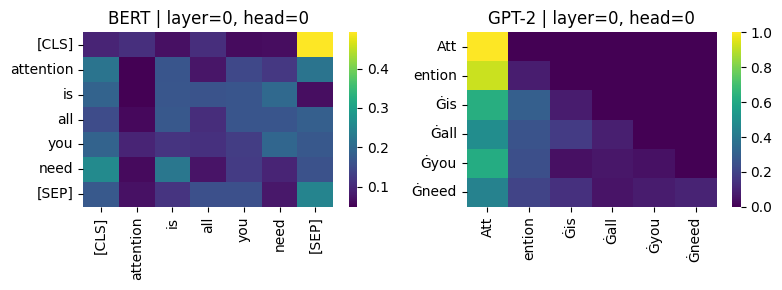

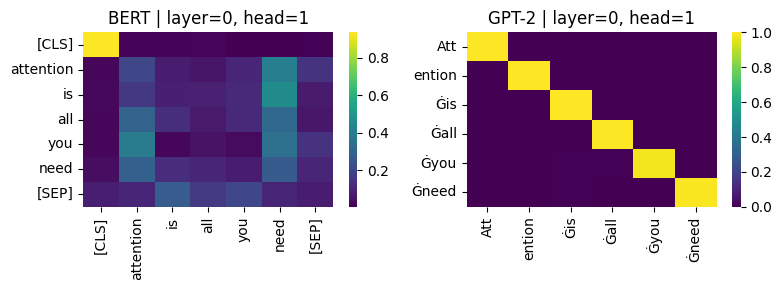

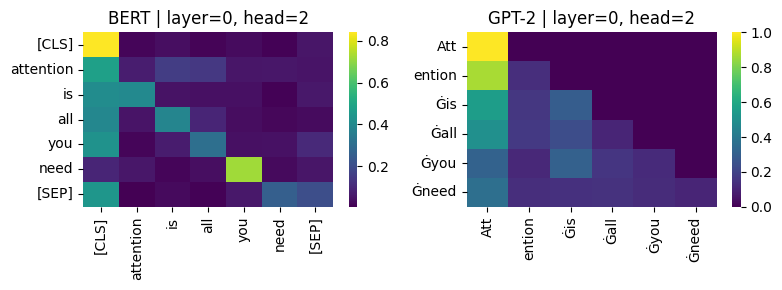

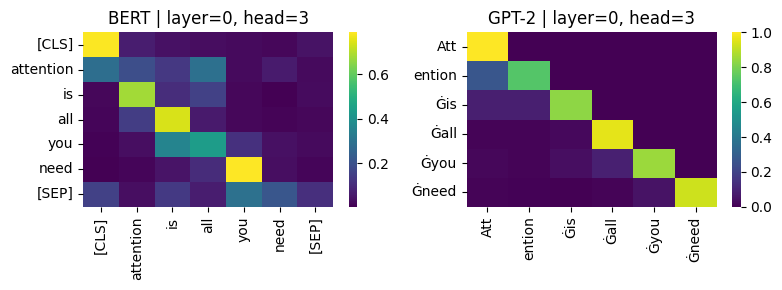

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_attention_heatmap(bert_attn, bert_tokens, layer=0, head=0, title="BERT", ax=axes[0])
plot_attention_heatmap(gpt2_attn, gpt2_tokens, layer=0, head=0, title="GPT-2", ax=axes[1])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_attention_heatmap(bert_attn, bert_tokens, layer=0, head=1, title="BERT", ax=axes[0])
plot_attention_heatmap(gpt2_attn, gpt2_tokens, layer=0, head=1, title="GPT-2", ax=axes[1])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_attention_heatmap(bert_attn, bert_tokens, layer=0, head=2, title="BERT", ax=axes[0])
plot_attention_heatmap(gpt2_attn, gpt2_tokens, layer=0, head=2, title="GPT-2", ax=axes[1])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_attention_heatmap(bert_attn, bert_tokens, layer=0, head=3, title="BERT", ax=axes[0])
plot_attention_heatmap(gpt2_attn, gpt2_tokens, layer=0, head=3, title="GPT-2", ax=axes[1])

plt.tight_layout()
plt.show()

## layers

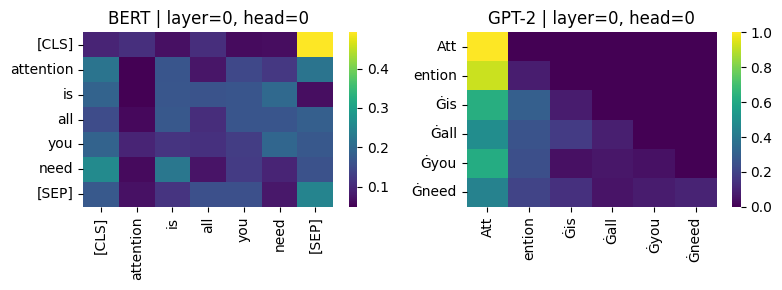

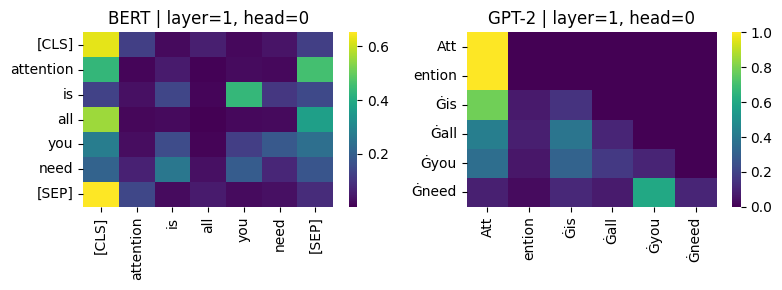

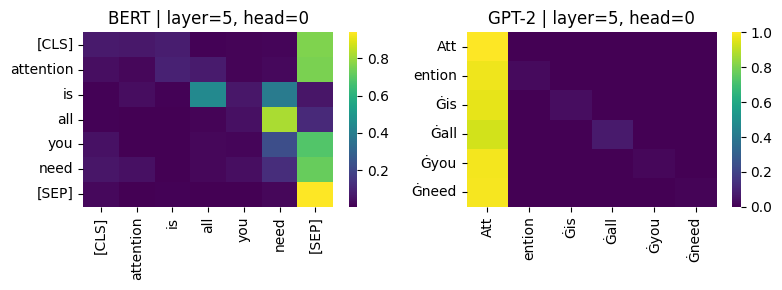

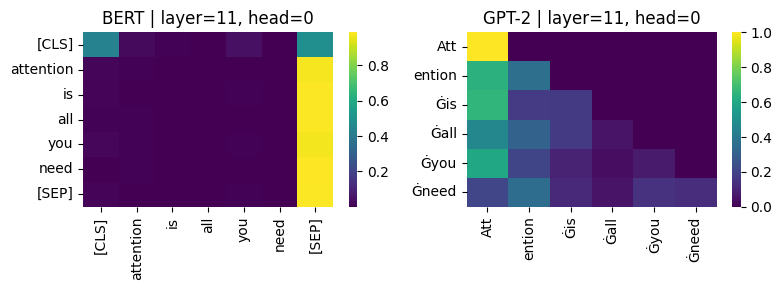

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_attention_heatmap(bert_attn, bert_tokens, layer=0, head=0, title="BERT", ax=axes[0])
plot_attention_heatmap(gpt2_attn, gpt2_tokens, layer=0, head=0, title="GPT-2", ax=axes[1])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_attention_heatmap(bert_attn, bert_tokens, layer=1, head=0, title="BERT", ax=axes[0])
plot_attention_heatmap(gpt2_attn, gpt2_tokens, layer=1, head=0, title="GPT-2", ax=axes[1])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_attention_heatmap(bert_attn, bert_tokens, layer=5, head=0, title="BERT", ax=axes[0])
plot_attention_heatmap(gpt2_attn, gpt2_tokens, layer=5, head=0, title="GPT-2", ax=axes[1])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_attention_heatmap(bert_attn, bert_tokens, layer=11, head=0, title="BERT", ax=axes[0])
plot_attention_heatmap(gpt2_attn, gpt2_tokens, layer=11, head=0, title="GPT-2", ax=axes[1])

plt.tight_layout()
plt.show()



# Выводы по Attention

1) фиксируем голову (head=0), меняем слои (layer=0..3)
2) фиксируем слой (layer=0), меняем головы (head=0..3)

### BERT

Attention не ограничен направлением: токены могут смотреть и на слова слева, и на слова справа - см. верхнюю диагональ по сравнению с GPT-2.


### GPT-2

В каждом слое сохраняется характерная форма нижнего треугольника, потому что GPT-2 использует causal mask и не может смотреть в будущее.


##  ИТОГ:
✅ BERT = двунаправленное понимание текста

✅ GPT-2 = автогенерация по прошлому контексту (causal).

Это различие напрямую отражается в attention-heatmap-картах: у GPT-2 визуально наблюдается треугольная структура (запрещён просмотр будущих токенов), а у BERT внимание может распределяться по всей матрице.

В BERT также встречаются головы, выделяющие структурные токены ([CLS], [SEP], пунктуацию). В начало первой фразы вставляется токен [CLS]. В конец вставляется токен [SEP].

## Изменения по слоям

При сравнении слоев можно заметить общий тренд:

- ранние слои чаще показывают локальные зависимости (соседние токены, структура предложения);

- более глубокие слои начинают выделять более далекие связи.

- также периодически встречаются "диагональные матрицы", передающие контекст далее

## Специализация attention-голов

Разные головы внутри одного слоя могут демонстрировать различные паттерны:

- диагональные головы — внимание токена к самому себе, т.е. копирование/стабилизация представлений.  Наличие диагональных attention-голов выполняет роль передачи информации дальше, а другие головы отвечают за извлечение взаимосвязей между токенами.

- локальные головы — фокус на ближайших словах.

- глобальные головы — распределение внимания на более дальние позиции и ключевые элементы.


# Часть 2. Дополнительные задания

## Интерактивный просмотр attention (BERT)

In [17]:
from bertviz import head_view

head_view(bert_attn, bert_tokens)


<IPython.core.display.Javascript object>

## Интерактивный просмотр attention (GPT-2)

In [18]:
head_view(gpt2_attn, gpt2_tokens)

<IPython.core.display.Javascript object>

## Multi-Head Attention анализ

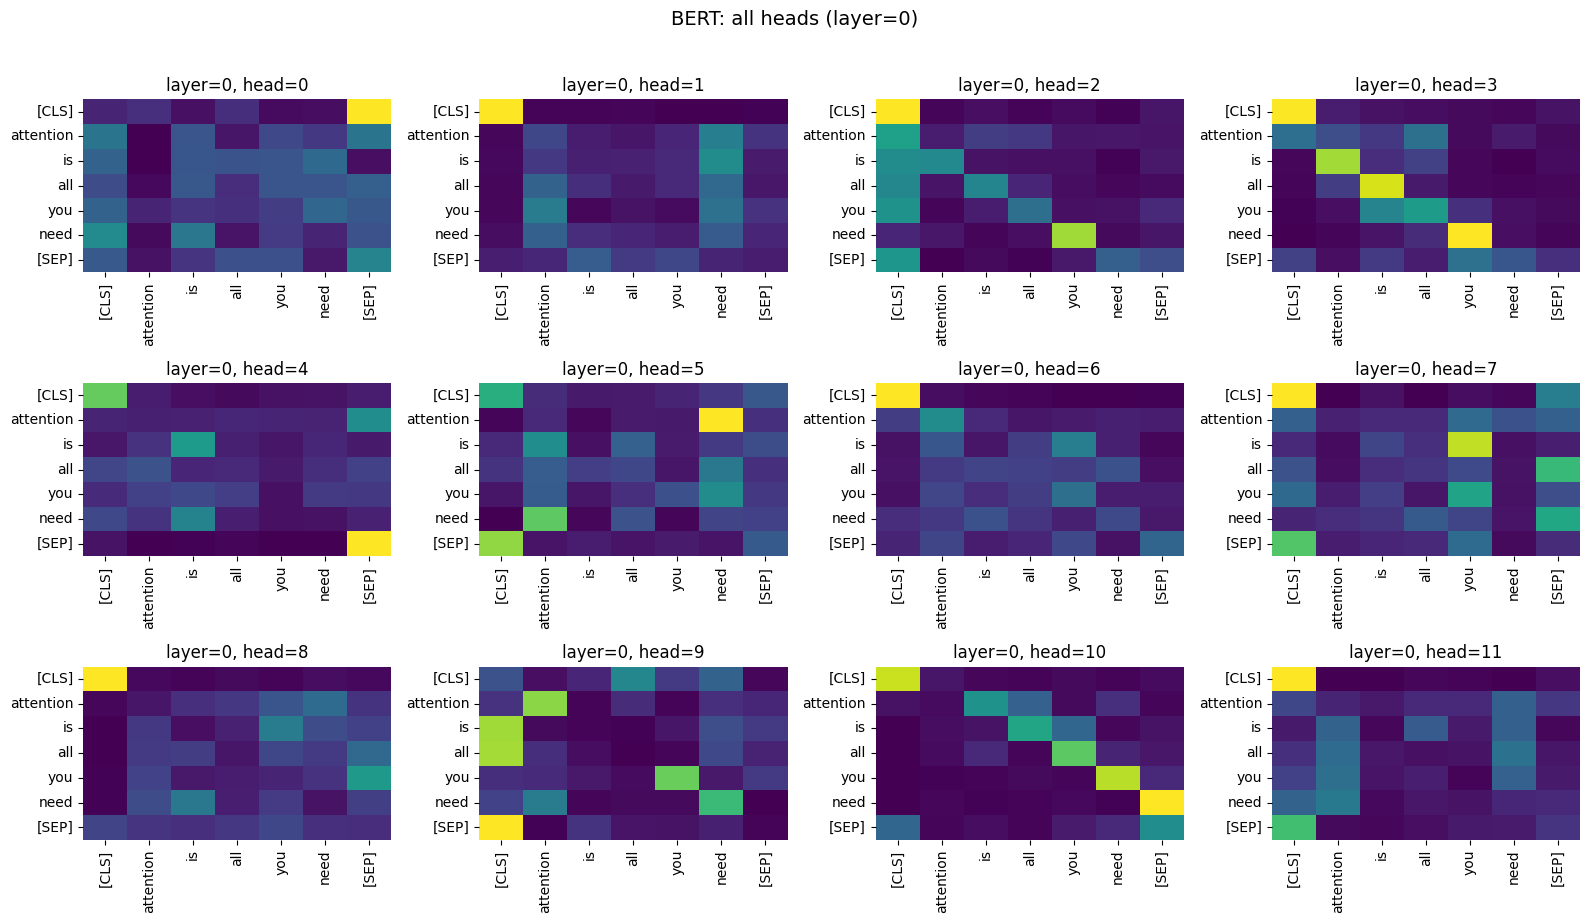

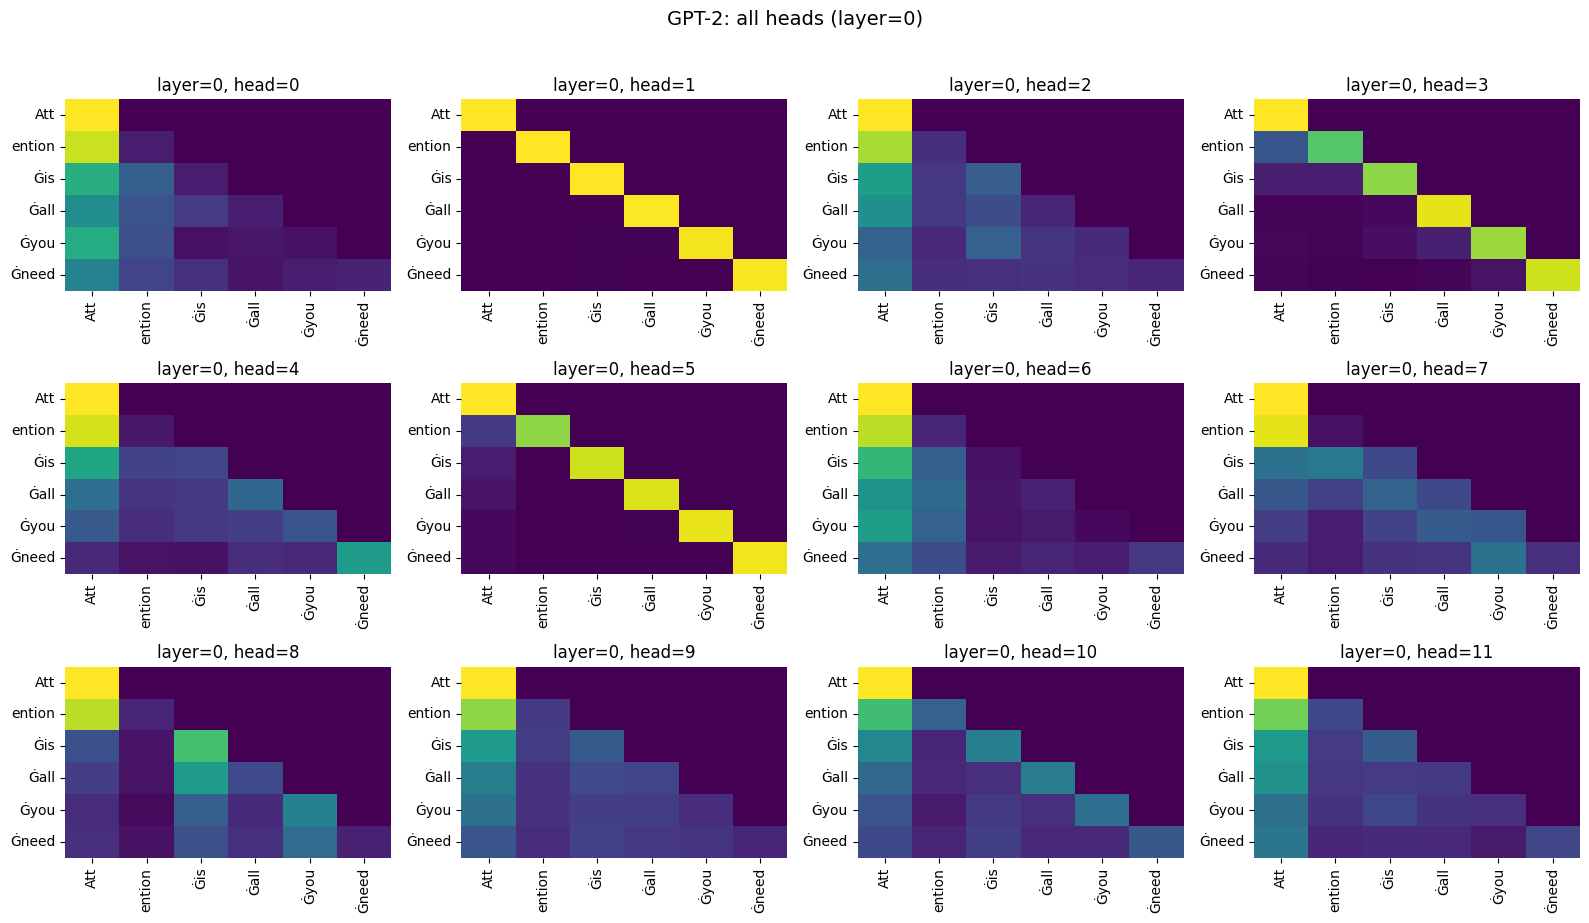

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_all_heads(attentions, tokens, layer=0, max_tokens=30, n_cols=4, title="All heads"):
    """
    Рисует attention heatmap для всех голов одного слоя.
    attentions[layer]: (batch, heads, seq_len, seq_len)
    """
    tokens = tokens[:max_tokens]
    attn_layer = attentions[layer][0, :, :max_tokens, :max_tokens].detach().cpu().numpy()  # (heads, n, n)
    num_heads = attn_layer.shape[0]

    n_rows = int(np.ceil(num_heads / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

    axes = np.array(axes).reshape(-1)

    for h in range(num_heads):
        ax = axes[h]
        sns.heatmap(attn_layer[h], ax=ax, xticklabels=tokens, yticklabels=tokens, cbar=False, cmap="viridis")
        ax.set_title(f"layer={layer}, head={h}")
        ax.tick_params(axis="x", rotation=90)
        ax.tick_params(axis="y", rotation=0)

    # пустые оси (если heads не кратно сетке)
    for k in range(num_heads, len(axes)):
        axes[k].axis("off")

    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


# Пример: все головы BERT на layer=0
plot_all_heads(bert_attn, bert_tokens, layer=0, max_tokens=30, title="BERT: all heads (layer=0)")

# Пример: все головы GPT-2 на layer=0
plot_all_heads(gpt2_attn, gpt2_tokens, layer=0, max_tokens=30, title="GPT-2: all heads (layer=0)")


## Кросс-языковое исследование: RuBERT

In [23]:
from transformers import AutoTokenizer, AutoModel

rubert_name = "DeepPavlov/rubert-base-cased"

rubert_tokenizer = AutoTokenizer.from_pretrained(rubert_name)
rubert_model = AutoModel.from_pretrained(rubert_name, output_attentions=True).to(device)
rubert_model.eval()

print("RuBERT loaded:", rubert_name)

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RuBERT loaded: DeepPavlov/rubert-base-cased


In [28]:
ru_text = "Внимание это все что нам нужно"
print(ru_text)

rubert_attn, rubert_tokens = get_attention(rubert_model, rubert_tokenizer, ru_text, device=device)

print("RuBERT layers:", len(rubert_attn), "heads:", rubert_attn[0].shape[1], "seq_len:", rubert_attn[0].shape[-1])
print("RuBERT tokens:", rubert_tokens)


Внимание это все что нам нужно
RuBERT layers: 12 heads: 12 seq_len: 8
RuBERT tokens: ['[CLS]', 'Внимание', 'это', 'все', 'что', 'нам', 'нужно', '[SEP]']


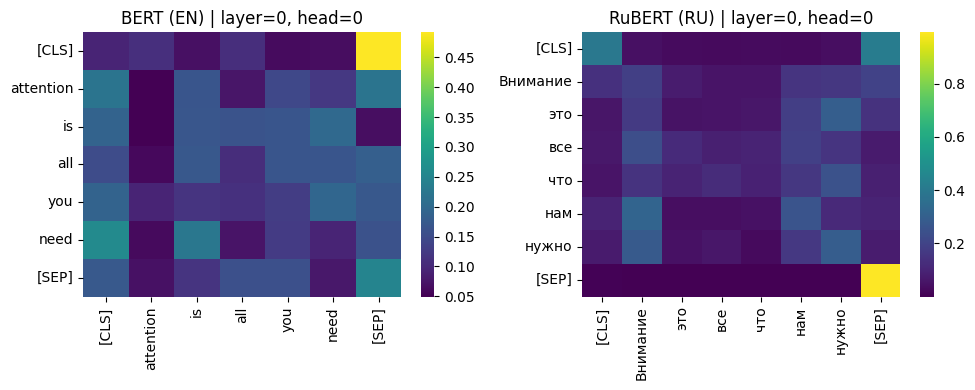

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_attention_heatmap(bert_attn, bert_tokens, layer=0, head=0, title="BERT (EN)", ax=axes[0])
plot_attention_heatmap(rubert_attn, rubert_tokens, layer=0, head=0, title="RuBERT (RU)", ax=axes[1])

plt.tight_layout()
plt.show()


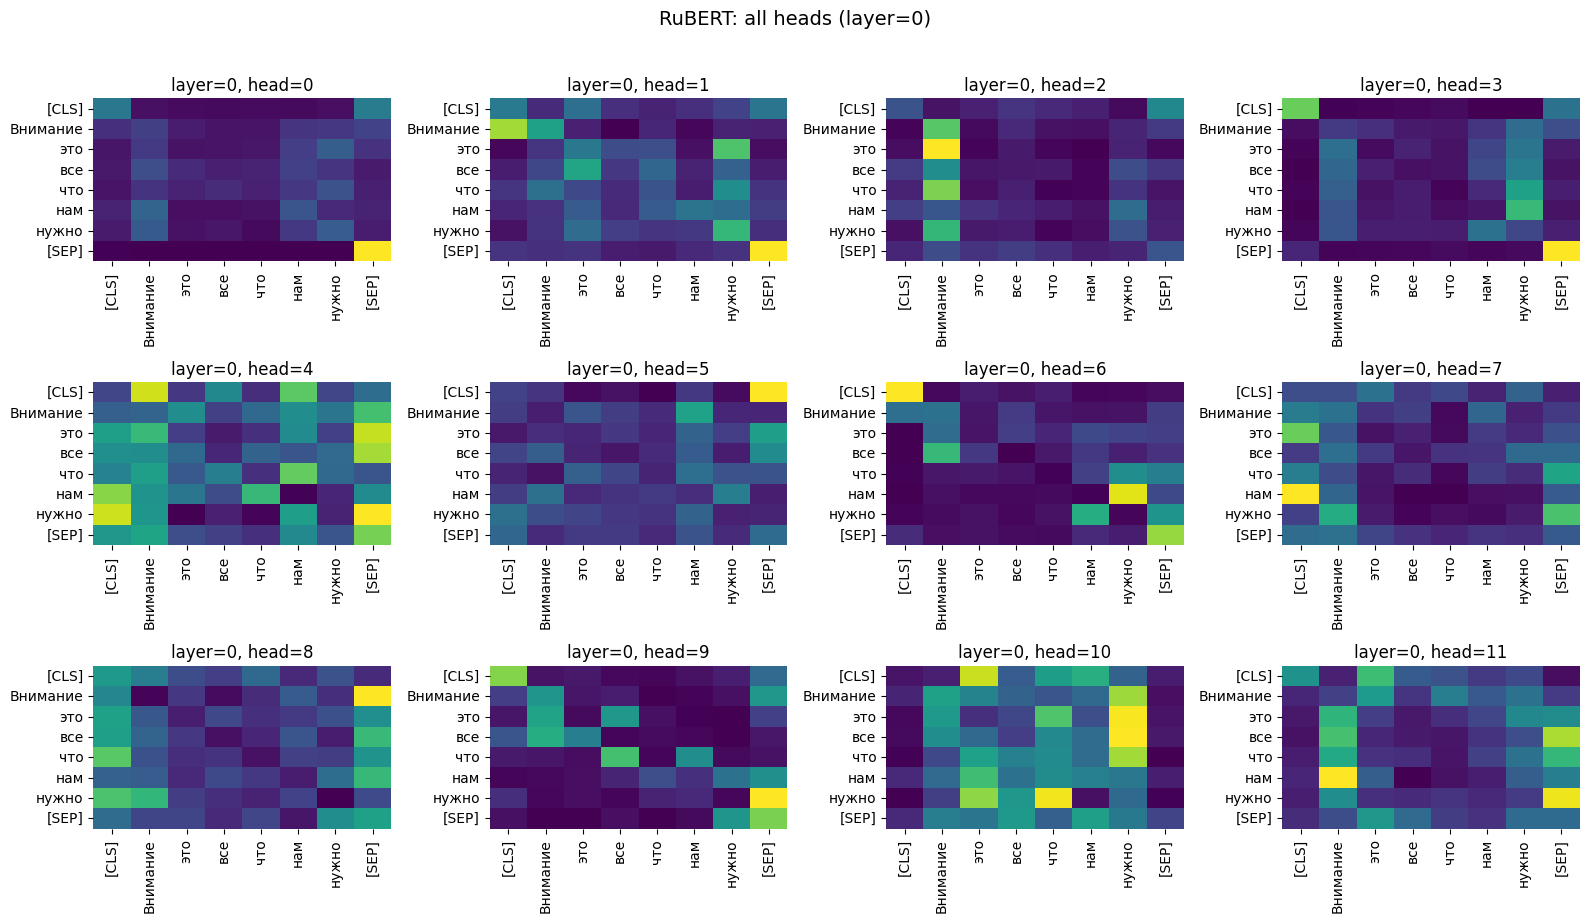

In [32]:
plot_all_heads(rubert_attn, rubert_tokens, layer=0, max_tokens=30, title="RuBERT: all heads (layer=0)")

In [46]:
ru_text = """На краю дороги стоял дуб. Вероятно, в десять раз старше берез, составлявших лес, он был в десять раз толще, и в два раза выше каждой березы."""

print(ru_text)

rubert_attn, rubert_tokens = get_attention(rubert_model, rubert_tokenizer, ru_text, device=device)

print("RuBERT layers:", len(rubert_attn), "heads:", rubert_attn[0].shape[1], "seq_len:", rubert_attn[0].shape[-1])
print("RuBERT tokens:", rubert_tokens)


На краю дороги стоял дуб. Вероятно, в десять раз старше берез, составлявших лес, он был в десять раз толще, и в два раза выше каждой березы.
RuBERT layers: 12 heads: 12 seq_len: 35
RuBERT tokens: ['[CLS]', 'На', 'краю', 'дороги', 'стоял', 'дуб', '.', 'Вероятно', ',', 'в', 'десять', 'раз', 'старше', 'берез', ',', 'составлявших', 'лес', ',', 'он', 'был', 'в', 'десять', 'раз', 'толще', ',', 'и', 'в', 'два', 'раза', 'выше', 'каждой', 'берез', '##ы', '.', '[SEP]']


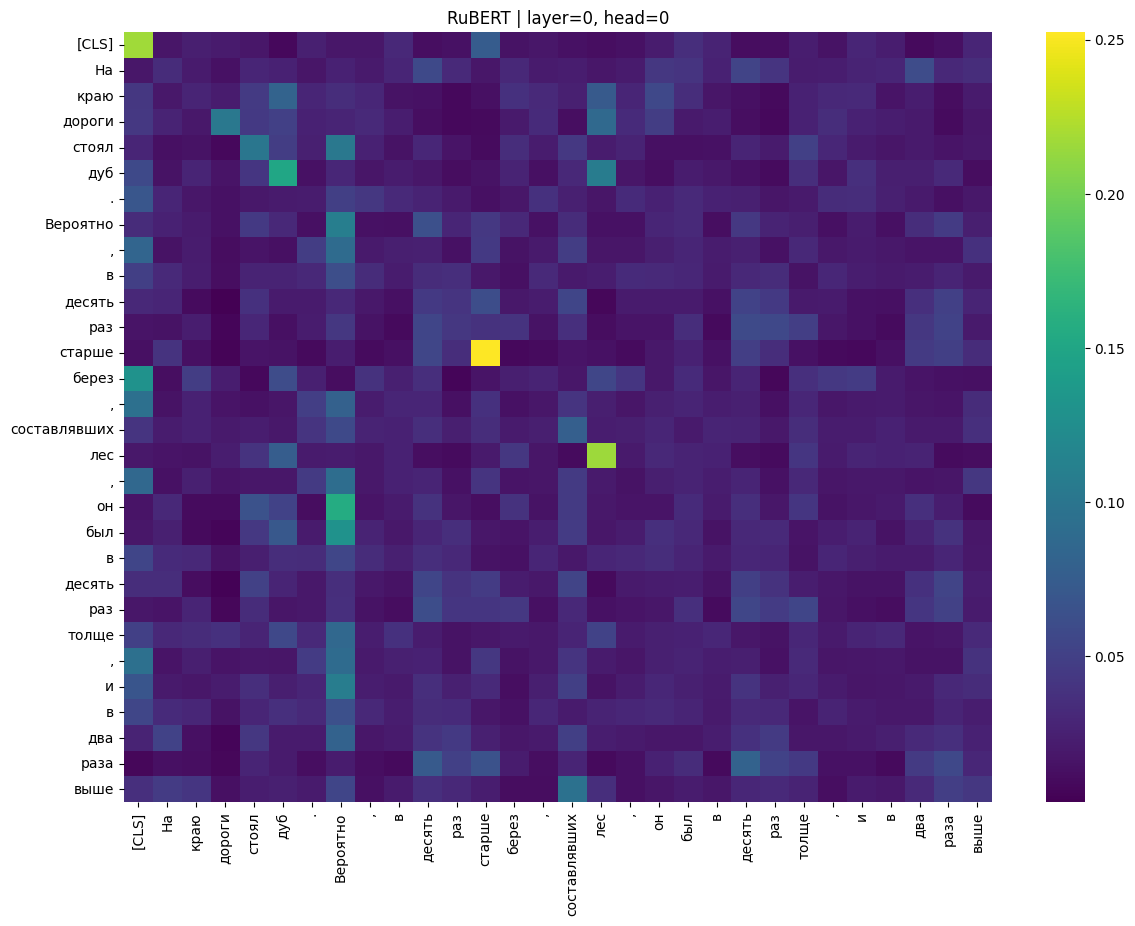

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
plot_attention_heatmap(rubert_attn, rubert_tokens, layer=0, head=0, title="RuBERT", ax=ax)
plt.show()


EN text: Alice went to the store after work because she needed milk for breakfast. On the way, she met Bob, and they talked about the new university project. Later, Alice told him that she would return home early because she was tired.
RU text: Алиса после работы пошла в магазин, потому что ей нужно было молоко на завтрак. По дороге она встретила Боба, и они поговорили о новом проекте в университете. Позже Алиса сказала ему, что вернётся домой пораньше, потому что устала.

BERT tokens count: 49
RuBERT tokens count: 51


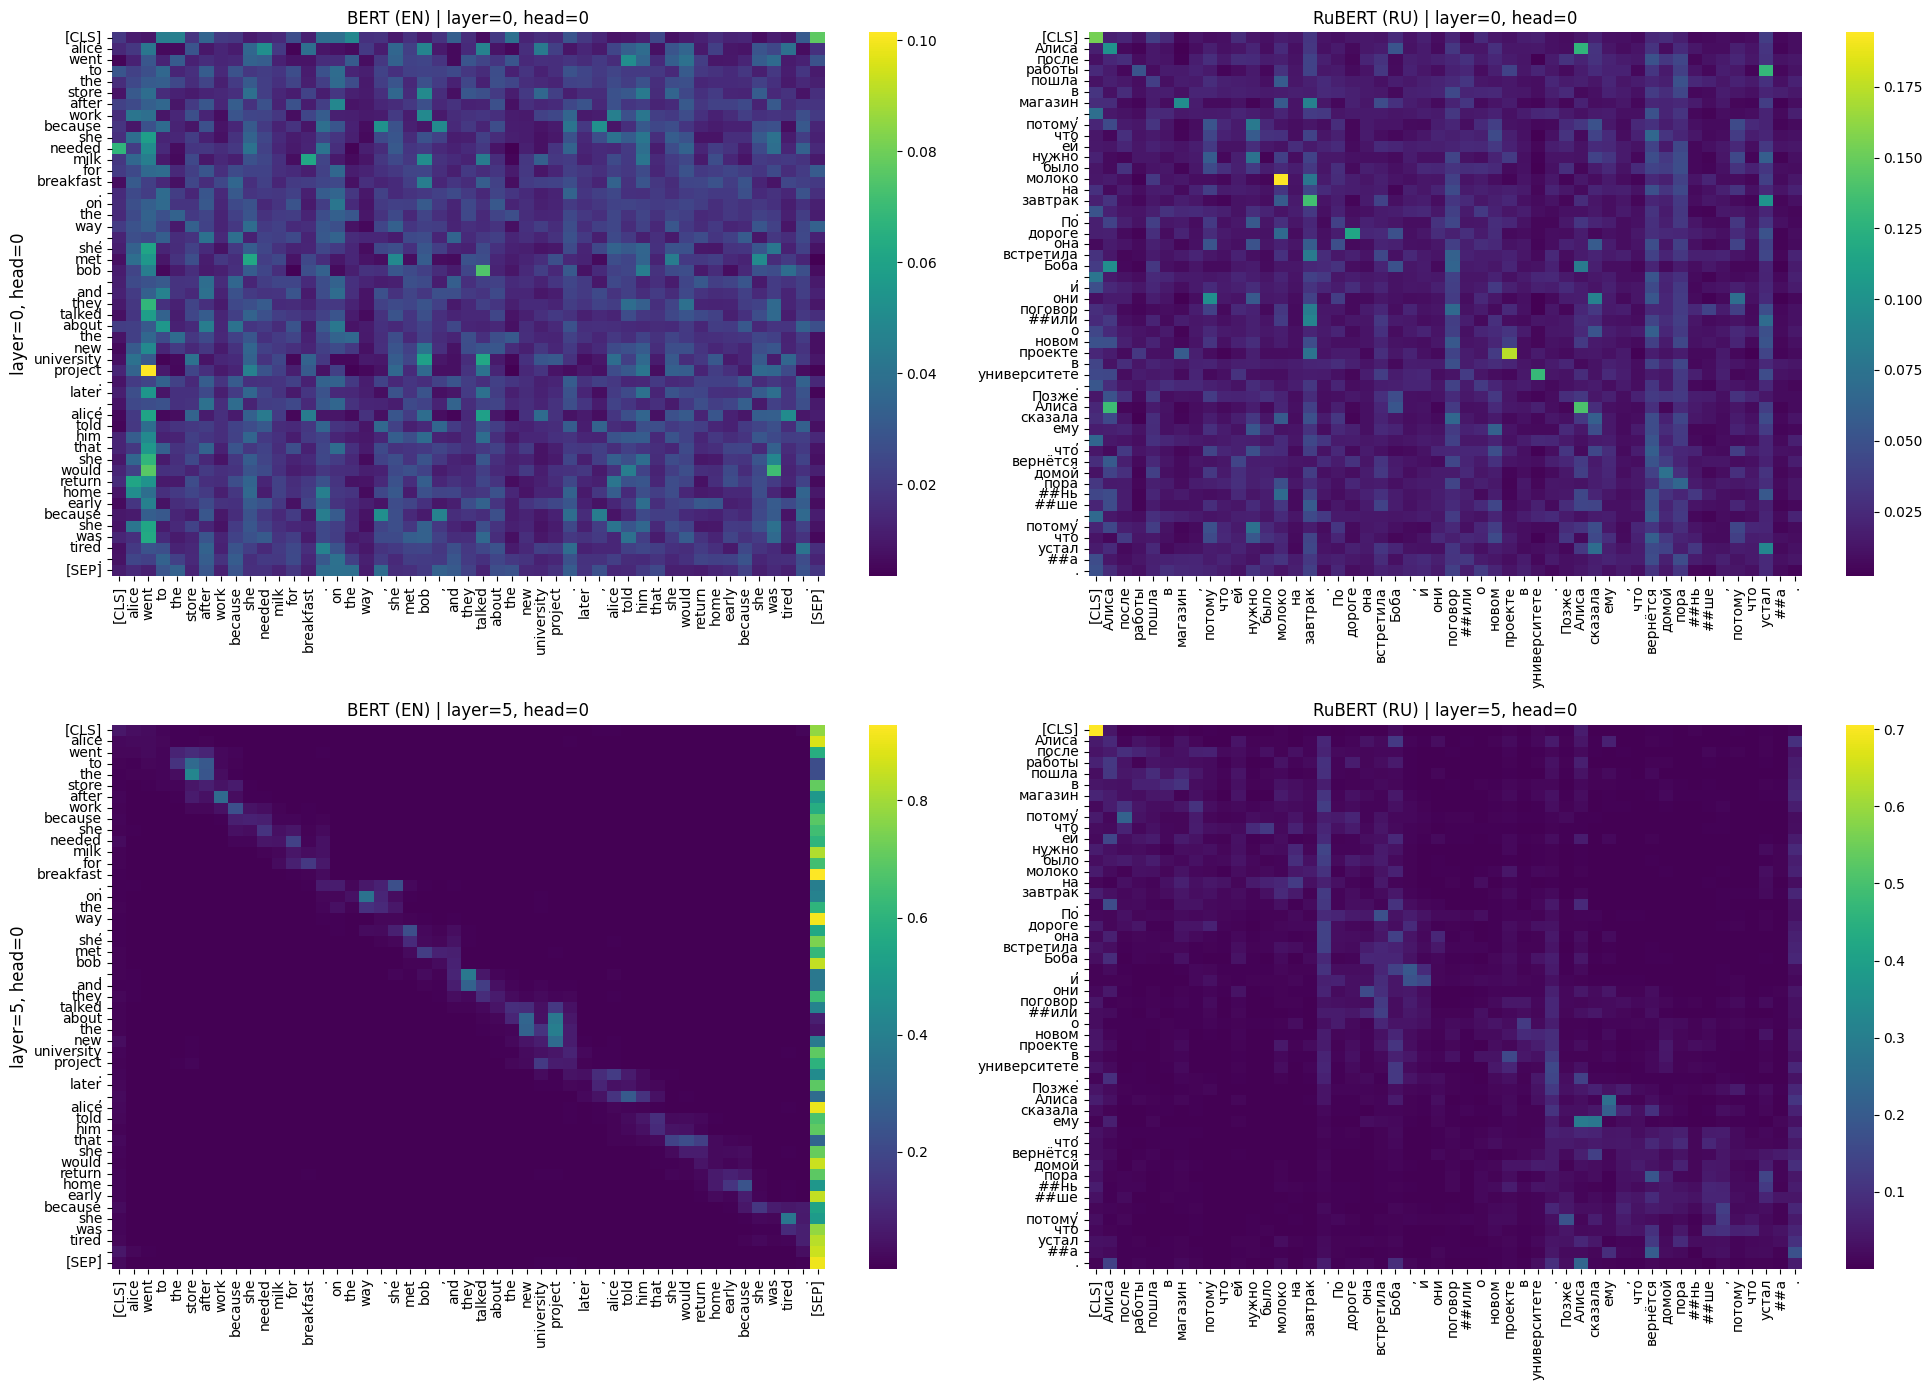

In [56]:

en_text = (
    "Alice went to the store after work because she needed milk for breakfast. "
    "On the way, she met Bob, and they talked about the new university project. "
    "Later, Alice told him that she would return home early because she was tired."
)

ru_text = (
    "Алиса после работы пошла в магазин, потому что ей нужно было молоко на завтрак. "
    "По дороге она встретила Боба, и они поговорили о новом проекте в университете. "
    "Позже Алиса сказала ему, что вернётся домой пораньше, потому что устала."
)

bert_attn_long, bert_tokens_long = get_attention(bert_model, bert_tokenizer, en_text, device=device)
rubert_attn_long, rubert_tokens_long = get_attention(rubert_model, rubert_tokenizer, ru_text, device=device)

print("EN text:", en_text)
print("RU text:", ru_text)

print("\nBERT tokens count:", len(bert_tokens_long))
print("RuBERT tokens count:", len(rubert_tokens_long))

layer_top = 0
layer_mid = 5
head = 0
max_tokens = 50

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# --- layer 0 ---
plot_attention_heatmap(
    bert_attn_long, bert_tokens_long, layer=layer_top, head=head,
    title="BERT (EN)", max_tokens=max_tokens, ax=axes[0, 0]
)
plot_attention_heatmap(
    rubert_attn_long, rubert_tokens_long, layer=layer_top, head=head,
    title="RuBERT (RU)", max_tokens=max_tokens, ax=axes[0, 1]
)

# --- layer 5 ---
plot_attention_heatmap(
    bert_attn_long, bert_tokens_long, layer=layer_mid, head=head,
    title="BERT (EN)", max_tokens=max_tokens, ax=axes[1, 0]
)
plot_attention_heatmap(
    rubert_attn_long, rubert_tokens_long, layer=layer_mid, head=head,
    title="RuBERT (RU)", max_tokens=max_tokens, ax=axes[1, 1]
)

axes[0, 0].set_ylabel(f"layer={layer_top}, head={head}", fontsize=12)
axes[1, 0].set_ylabel(f"layer={layer_mid}, head={head}", fontsize=12)

plt.tight_layout()
plt.show()


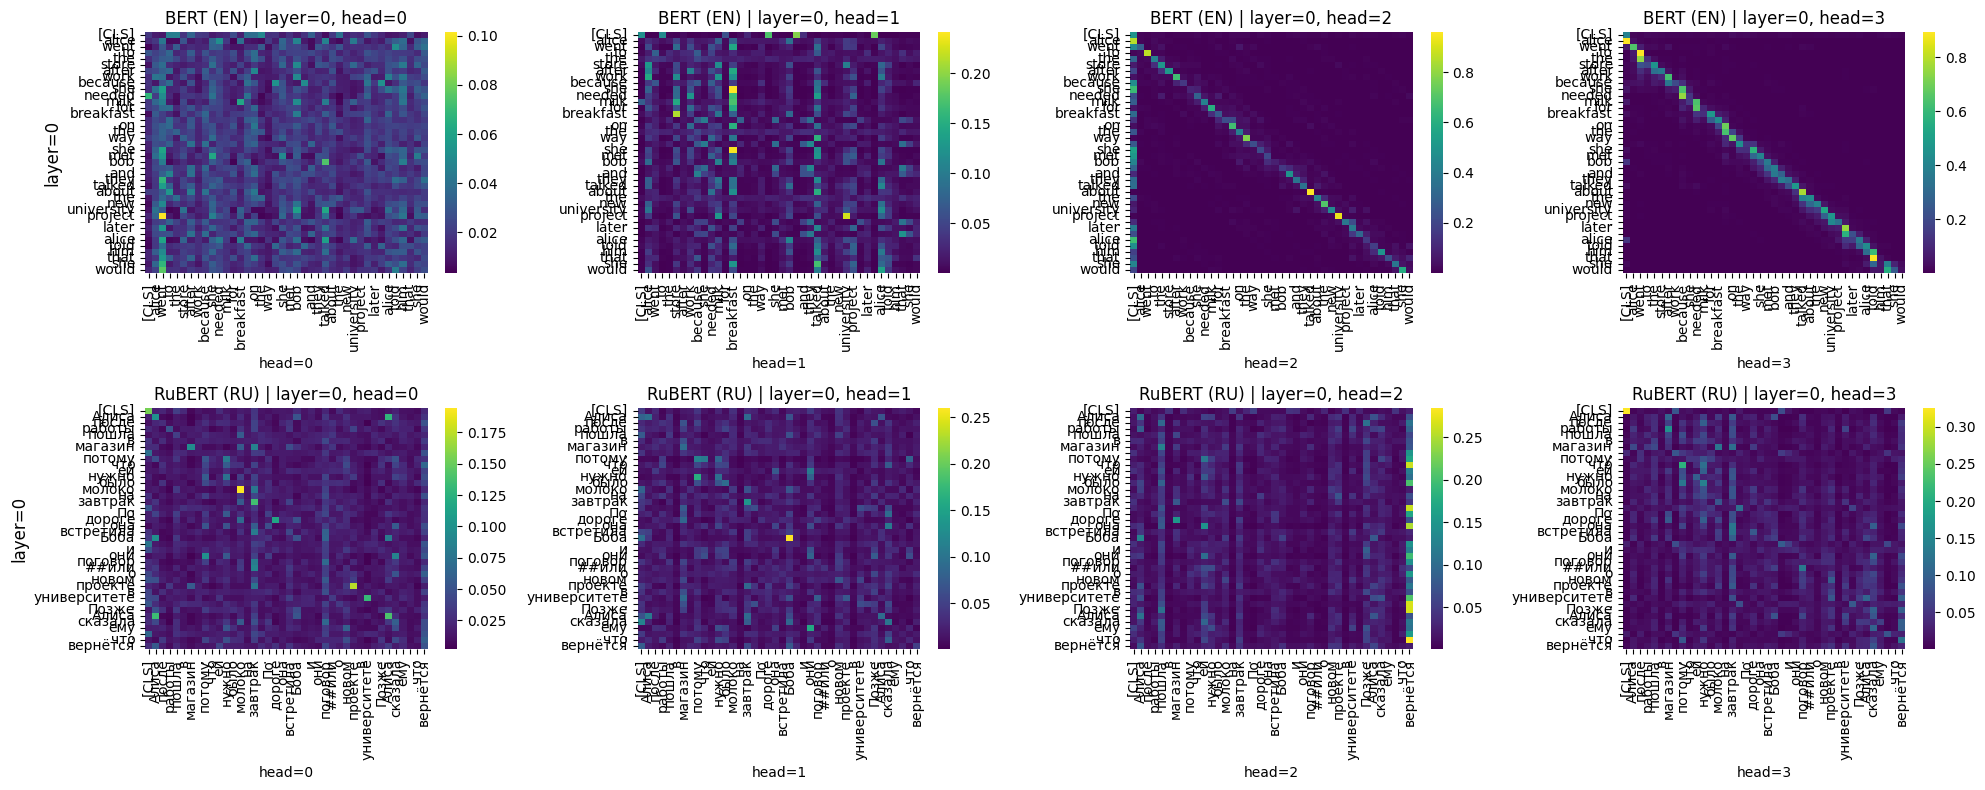

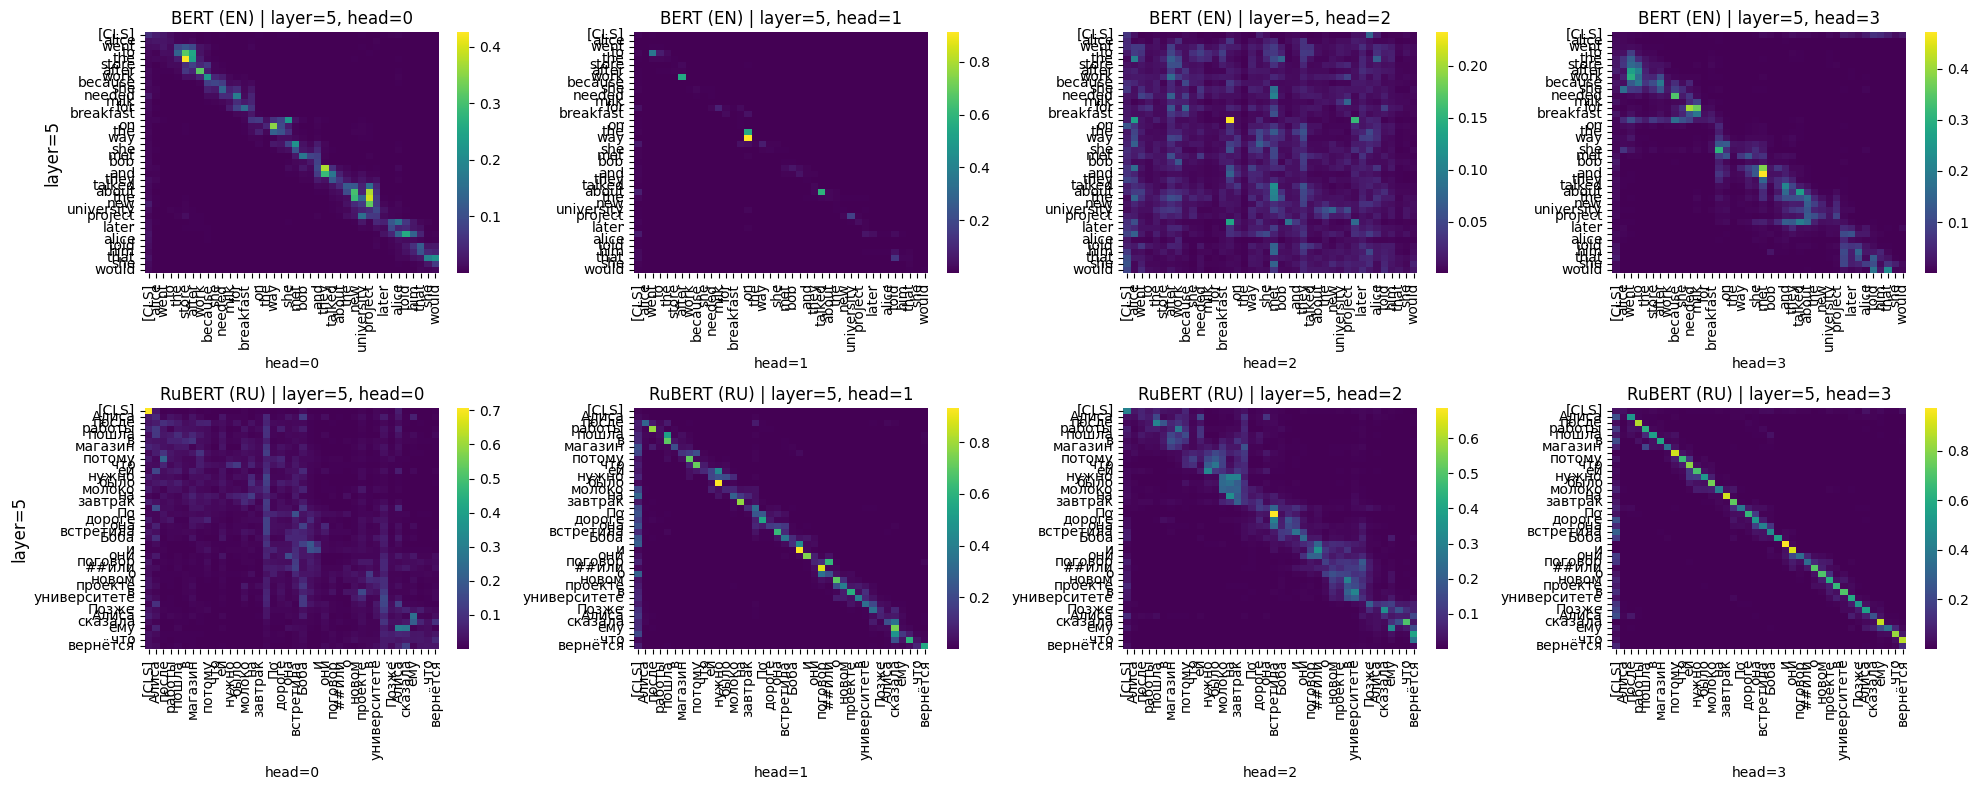

In [58]:
import matplotlib.pyplot as plt

def compare_heads_one_layer(attn_a, tok_a, attn_b, tok_b, layer=0, heads=(0,1,2,3), max_tokens=40,
                            name_a="BERT (EN)", name_b="RuBERT (RU)"):
    fig, axes = plt.subplots(2, len(heads), figsize=(5*len(heads), 8))

    for j, h in enumerate(heads):
        plot_attention_heatmap(attn_a, tok_a, layer=layer, head=h, title=name_a,
                               max_tokens=max_tokens, ax=axes[0, j])
        plot_attention_heatmap(attn_b, tok_b, layer=layer, head=h, title=name_b,
                               max_tokens=max_tokens, ax=axes[1, j])

        axes[0, j].set_xlabel(f"head={h}")
        axes[1, j].set_xlabel(f"head={h}")

    axes[0, 0].set_ylabel(f"layer={layer}", fontsize=12)
    axes[1, 0].set_ylabel(f"layer={layer}", fontsize=12)

    plt.tight_layout()
    plt.show()


# Примеры: головы 0..3 на слое 0 и слое 5
compare_heads_one_layer(bert_attn_long, bert_tokens_long, rubert_attn_long, rubert_tokens_long,
                        layer=0, heads=(0,1,2,3), max_tokens=40)

compare_heads_one_layer(bert_attn_long, bert_tokens_long, rubert_attn_long, rubert_tokens_long,
                        layer=5, heads=(0,1,2,3), max_tokens=40)


## Вывод

Загружена русскоязычная модель RuBERT и выполнена визуализация attention для русского текста. Далее результаты были сопоставлены с англоязычным BERT на аналогичном по смыслу и размеру тексте.

RuBERT и BERT имеют одинаковую архитектурную основу и используют двунаправленное внимание.

На русском тексте часто заметно внимание вокруг диагонали и ближайших токенов.

В русской модели чаще проявляется разбиение на субтокены внутри одного слова, соответственно, на этом также концентрируется внимание.

# Итоговый анализ

Визуализация Attention позволяет заглянуть внутрь трансформера и понять, как модель распределяет фокус внимания между токенами.

Attention-карты позволяют проверить:
- на какие токены смотрела модель,
- что оказалось важным для внимания, а что проигнорировано.

Анализ механизма внимания помогает интерпретировать и объяснять результаты модели, находить ошибки в масках/паддинге/токенизации и принимать решения при выборе и отладке моделей.

Таким образом, можно визуализировать работу self-attention и понять, как модель «видит» текст.